# Лекция. Подтверждающий анализ данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp
from scipy.stats import chi2_contingency

## §1. Введение в CDA: зачем нам статистика, если есть графики?

Мы уже умеем строить графики. Мы умеем считать среднее, медиану, стандартное отклонение. Некоторые из нас, возможно, даже умеют делать `boxplot` — эту коробочку с усами, которая так красиво выглядит и так коварно обманывает.

И вот перед нами две группы. Мы смотрим на `boxplot` и думаем: «Они разные. Вывод готов, можно расходиться».

Однако не стоит торопиться.

Графики — это разведка. EDA (Exploratory Data Analysis) — это когда мы смотрим на данные и говорим: «Кажется, тут что-то есть». Но «кажется» — это не аргумент для научной статьи, отчёта перед начальником или защиты диплома.

Нам нужен судья. Судья, который посмотрит на те же данные и скажет: «Да, различия статистически значимы, вероятность ошибки — 3%» или «Нет, это шум, мы ничего не нашли».

В качестве такого судьи в аналиде занных выступает статистический критерий. А процесс вынесения вердикта называется CDA — Confirmatory Data Analysis, или подтверждающий анализ данных.

**Цель сегодняшней лекции:** научиться не просто видеть разницу на графиках, а доказывать её существование с помощью статистических критериев. Или опровергать — что честнее, между прочим.

Начнём с того, почему глазам верить нельзя.


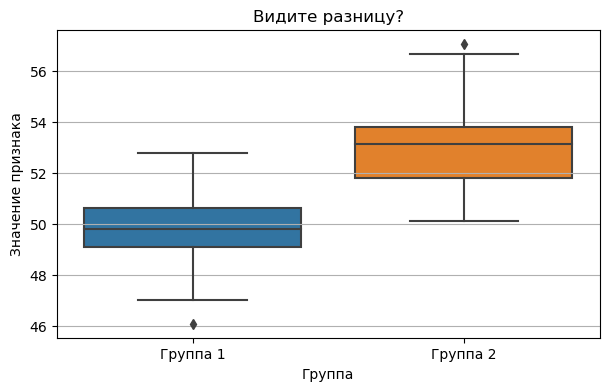

In [2]:
np.random.seed(42)

group_1 = np.random.normal(loc=50, scale=1.5, size=100)
group_2 = np.random.normal(loc=53, scale=1.5, size=100)

df_plot = pd.DataFrame({
    'value': np.concatenate([group_1, group_2]),
    'group': ['Группа 1'] * 100 + ['Группа 2'] * 100
})

plt.figure(figsize=(7, 4))

sns.boxplot(data=df_plot, x='group', y='value')

plt.title('Видите разницу?')
plt.ylabel('Значение признака')
plt.xlabel('Группа')
plt.grid(axis='y')

plt.show()

Коробочки не пересекаются, медианы далеко, усы едва задевают друг друга. Очевидно, что группы разные. Можно закрывать презентацию и идти пить ~~пиво в бар~~ кофе в кофейню. Но подождите. Вот те же группы, но с большим разбросом:

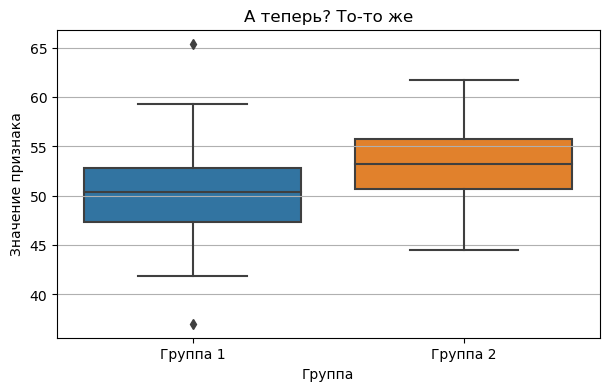

In [3]:
group_1_nois = np.random.normal(loc=50, scale=4.0, size=100)
group_2_nois = np.random.normal(loc=53, scale=4.0, size=100)

df_plot_nois = pd.DataFrame({
    'value': np.concatenate([group_1_nois, group_2_nois]),
    'group': ['Группа 1'] * 100 + ['Группа 2'] * 100
})

plt.figure(figsize=(7, 4))
sns.boxplot(data=df_plot_nois, x='group', y='value')
plt.title('А теперь? То-то же')
plt.ylabel('Значение признака')
plt.xlabel('Группа')
plt.grid(axis='y')
plt.show()

Вы всё ещё уверены, что группы разные?

Коробки перекрываются. Усы — еще сильнее перекрываются. Если кому-нибудь показать эти данные и не сказать, где какая группа, он наверняка решит, что это одна большая совокупность однотипных значений. Средние в группах различаются примерно на те же 3 единицы. Но в первом случае — разница очевидна. А во втором — сомнительна. А ведь это одни и те же данные по своей природе, просто во втором случае мы увеличили разброс (с 1.5 до 4.0).

Мораль в том, что разница средних — это еще полдела. Потому что нужно учитывать еще и разброс. И размер выборки. И форму распределения. И так далее. Глаза это не видят, глаза видят только красивые картинки. Поэтому графики и EDA — это разведка. А CDA — это когда мы говорим статистике: «Скажи, статистика, можем ли мы доверять своим глазам?»

## § 2. Библиотеки:  достаточно одной scipy, но есть нюансы

Итак, мы только что убедились: глаза нас обманывают. Графики могут показывать разницу там, где её нет, и наоборот — могут скрывать разницу там, где она есть. Выход в том, чтобы обратиться к судье из библиотеки. Не той, где книги и тишина, а  той, где 
```python
from scipy import stats
```
Модуль `stats` — это наш швейцарский нож для статистических тестов. В этой библиотеке есть практически всё, что понадобится для CDA.

#### Сравнение групп

- ttest_ind — t-критерий для двух независимых выборок (параметрический),

- mannwhitneyu — U-критерий Манна-Уитни (непараметрический),

- f_oneway — однофакторный дисперсионный анализ (ANOVA),

- kruskal — H-критерий Краскела-Уоллиса (непараметрическая альтернатива ANOVA).


#### Связи между переменными

- pearsonr — корреляция Пирсона (линейная),

- spearmanr — корреляция Спирмена (ранговая).


#### Проверка условий


- shapiro — критерий Шапиро-Уилка на нормальность,

- levene — критерий Левене на равенство дисперсий.


#### Таблицы сопряжённости


- chi2_contingency — критерий хи-квадрат,

- fisher_exact — точный критерий Фишера.


Базовый синтаксис всех этих методов до неприличия прост:
```python
stats.method(group_1, group_2)
```
— и на выходе мы получаем два числа: значение критерия и p-value. Что такое p-value — мы разберём через пару минут, пока просто запомните: **чем меньше p-value, тем круче**. Меньше — значит, ваши глаза не обманули, разница реальна.

#### Дополнительные инструменты

- Билиотека statsmodels — более продвинутая библиотека. Нужна, когда тестов много, нужны поправки на множественные сравнения и т. д.

- И ставшая уже родной библиотека pandas — для выяснения обстоятельств перед тестом: посчитать средние, медианы, посмотреть на распределение и т. д. Без неё никуда.

  
Теперь, зная, чем пользоваться, давайте разберёмся, как это работает и что означают цифры на выходе. Потому что запустить тест — это секунда. А понять, что он говорит — вот это уже сложнее.

In [4]:
stat, p_value = stats.ttest_ind(group_1_nois, group_2_nois)

print('t-статистика:', round(stat, 4))
print('p-value:     ', round(p_value, 4))

if p_value < 0.05:
    print('Разница статистически значима (p < 0.05)')
else:
    print('Разница не значима (p ≥ 0.05)')

t-статистика: -5.6606
p-value:      0.0
Разница статистически значима (p < 0.05)


Смотрите, что произошло.

На втором графике мы визуально сомневались, есть ли разница. Многие из нас, глядя на коробки с усами, сказали: «Да там всё перемешано, нет никакой разницы». А t-критерий сказал: «Разница есть. p-value = 0.00000, то есть меньше 0.00001. Вероятность ошибиться, утверждая, что группы разные — менее одной тысячной процента».

Глаза сомневались — статистика сказала: «Не сомневайся». Но это мы забежали вперёд. Давайте разберёмся, что стоит за этим p-value, как работают гипотезы и почему 0.05 — это магическое число (хотя и не совсем магическое, а вполне себе договорное).

## 3. Что такое статистический критерий?

Итак, инструменты мы назвали. Теперь давайте разберёмся, что это за зверь такой — статистический критерий.

Представьте суд. В суде есть судья. А у него на столе — есть улики, в качестве которых выступают наши данные. У судьи две версии: «Подсудимый виновен» и «Подсудимый невиновен», а его задача — посмотреть на улики и вынести вердикт. Так вот, статистический критерий — это и есть такой судья. Он берёт данные, смотрит на них, что-то считает и выносит вердикт: отклоняет или не отклоняет гипотезу. Только вместо «виновен/невиновен» у него формулировки скучнее (но суть та же).

**Формальное определение:** статистический критерий — это правило, которое позволяет принять или отклонить гипотезу на основе имеющихся данных.

Внутри у критерия находится распределение, которое «знаетМ, как ведут себя данные, если «ничего не происходит». А ещё у критерия есть чуткость, или мощность, — способность заметить эффект изменения, если он есть.

В статистике есть три большие партии критериев. Они конкурируют, но каждая по-своему симпатична.

#### 1. Параметрические критерии

Это требовательные и взыскательные зануды. Они требуют, чтобы данные были распределены нормально и чтобы дисперсии распределений были однородны. Но если условия соблюдены — они работают как часы: чуткие, мощные и точные. Самые популярные среди них: t-критерий (для двух групп), ANOVA, или дисперсионный анализ (для трёх и более групп), корреляция Пирсона (для связи между количественными переменными)

#### 2. Непараметрические критерии

Это демократы. Им всё равно, нормальные у вас данные или нет. Они не смотрят на форму распределения — они смотрят на порядок, на ранги. Они немного менее чуткие, чем параметрические (чуть хуже видят эффект, если он есть), но зато работают с любыми данными: искажёнными, с выбросами и т.д. Самые популярные: U-критерий Манна-Уитни (аналог t-критерия), H-критерий Краскела-Уоллиса (аналог ANOVA), корреляция Спирмена (аналог корреляции Пирсона, только по рангам)

#### 3. Специальные критерии

Это узкие специалисты. Они не сравнивают группы в лоб — они проверяют условия. Например, критерий Шапиро-Уилка — проверяет, нормально ли распределены данные. А критерий Левене — проверяет, равны ли дисперсии у групп. Эти ребята — как контролёры,  их задействуют перед основным тестом: «Всё ли в порядке? Можно ли применять параметрический критерий?»

#### Правило простое, как три копейки:

- Если данные нормальные и дисперсии равны → используйте параметрический критерий.
- Если данные не нормальные или дисперсии не равны → используйте непараметрический аналог.
- Если вы не знаете, или выборка маленькая (n < 30) → лучше перестрахуйтесь и берите непараметрический. Потеряете немного в мощности, но не ошибётесь.

Грубо, но по-рабочему.

#### Шпаргалка: кто есть кто в мире статистических критериев

**Параметрические:**
  - t-критерий (`ttest_ind`)
  - ANOVA (`f_oneway`)
  - Корреляция Пирсона (`pearsonr`)

**Непараметрические:**
  - U-критерий Манна-Уитни (`mannwhitneyu`)
  - Краскела-Уоллиса (`kruskal`)
  - Корреляция Спирмена (`spearmanr`)

**Специальные:**
  - Шапиро-Уилка (`shapiro`) — на нормальность
  - Левене (`levene`) — на равенство дисперсий

Пока мы ничего не считаем — просто запоминаем, кто есть кто. Сейчас нам важнее понять дугую концепцию: критерий — это судья, а не гадалка. Он не говорит «да» или «нет» с абсолютной уверенностью. Он говорит: **«С такой-то вероятностью я могу ошибиться, если скажу "да"»**.

## § 4. Гипотезы, уровень значимости, p-value

Итак, у нас есть судья, это статистический критерий. У него есть алгоритм. Но чтобы вынести вердикт, ему нужен закон — то есть правило, по которому он принимает решение.

Это правило состоит из трёх вещей:

- гипотезы (что мы проверяем),
- уровеня значимости α (какую ошибку мы готовы допустить),
- p-value (что нам сказали данные),
 

Давайте по порядку.

### H₀ и H₁: две стороны медали

Любая проверка гипотез начинается с того, что мы формулируем два утверждения.

**H₀ (нулевая гипотеза):** «Ничего не происходит. Различий нет. Связи нет. Всё случайно».

Это наш "стандарт невиновности". По умолчанию мы считаем, что H₀ верна, пока не получим убедительных доказательств обратного.


**H₁ (альтернативная гипотеза):** «Эффект есть. Различия реальны. Связь существует».

Это то, что мы хотим доказать.


  
Важно то, что мы никогда не «доказываем» H₀. Мы либо **отвергаем H₀** (и тогда принимаем H₁), либо **не отвергаем H₀** (и тогда говорим: «недостаточно оснований считать, что эффект есть»).

Формулировка «не отвергаем» — не то же самое, что «принимаем». Как в суде: «вина не доказана» ≠ «доказана невиновность».



### Уровень значимости α: цена ошибки

Теперь самый нервный узел.

Когда мы говорим «Мы отвергаем H₀», мы можем ошибиться. Вдруг H₀ на самом деле верна, а мы сказали «нет, есть эффект»? Так вот, уровень значимости α — это вероятность, которую мы сознательно назначаем для такой ошибки.

Еще до того как мы посмотрели на данные, мы говорим сами себе: «Мы готовы ошибиться и сказать, что эффект есть, когда его нет, не более чем в 5% случаев». Или в 1%. Или в 10%. Как договоримся. Но обычно берут α = 0.05. Так исторически сложилось. Это конвенция. Как зеленый сигнал светофора (почему не синий? — так исторически сложилось).

Ключевой момент: α выбирается до эксперимента. 

### p-value: голос данных

А вот p-value — это совсем другая история. p-value — это вероятность получить такие же (или ещё более крайние) результаты, при условии, что H₀ верна.

То есть: p-value — это голос данных. Он говорит: «Если бы на самом деле ничего не происходило, насколько вероятно было бы увидеть такую картину?». Другими словами:

- если p-value маленький (меньше α), данные говорят: «Смотри, такое бывает крайне редко, если H₀ верна. Может, H₀ всё-таки не верна?»
- если p-value большой (больше или равен α), данные говорят: «Да запросто. Такое могло бы случиться и просто по случайности. Не спеши с выводами».


#### Правило

- если p-value < α → отвергаем H₀ (есть основания считать, что эффект есть)
- если p-value ≥ α → не отвергаем H₀ (недостаточно оснований)


### В чём разница? 

Разница в том, что α и p-value — это разные миры. Уровень значимости α — это наше решение. Мы говорим: «Будем считать результат значимым, если p-value упадёт ниже этого порога». Это выбор исследователя. А p-value — это свойство данных. Оно получается из выборки, и мы на него не влияем (если, конечно, не жульничаем).


#### Пример


Мы устанавливаем α = 0.05. Проводим тест. Получаем p-value = 0.03. Мы говорим: «p-value (0.03) меньше α (0.05) → отвергаем H₀». Но что это означает?
— Если бы H₀ была верна (никакого эффекта нет), то данные, которые мы получили (или ещё более экстремальные), встречались бы только в 3% случаев.
— Поскольку 3% — это меньше нашего порога в 5%, мы решаем, что H₀, скорее всего, неверна.

#### Еще один пример (на котах)

Представим, что ваш лектор (то есть, я) — судья на конкурсе котов. Я решил заранее: «Я буду считать объект котом, если его фактор котовости превысит 80 баллов» (допустим, мы умеем измерять этот фактор). Так вот, это мой порог. Мой α. Мой закон.

Приводят кота. И у него котофактор = 92. Получив такого кота, я говорю: «Да, это кот на уровне 80 баллов». 

Теперь вопрос: могу ли я сказать, что «Это кот на уровне 92 балла»?

Ответ — нет. Потому что 92 — это **свойство данного кота, а не правило отбора**. Если бы я заранее установил порог 92, то всех котов с котофактором 91 я бы забраковал. Но я этого не сделал. Я заранее выбрал 80.


То же самое с α:


- α — это наш порог, наша стратегия. Мы говорим: «В среднем мы готовы ошибиться в 5% случаев».
- p-value — это характеристика конкретного результата. Она говорит: «Этот результат настолько экстремален, что если бы H₀ была верна, такое бывало бы только в 3% случаев».


Если бы мы заявили: «Мы принимаем H₁ на уровне 0.03», — мы бы смешали две разные вещи: правило (α) и конкретное значение (p-value).

#### Но есть нюанс

Вы можете сказать: «Ну хорошо, а почему бы тогда не отчитываться по p-value, а не по α? Ведь p-value даёт больше информации!» И это правильно. Современная статистика именно так и делает. Хороший тон — публиковать точное p-value (p = 0.023), а не просто «p < 0.05». Но решение о том, считать результат значимым или нет, всё равно принимается относительно α.


Почему? Потому что если мы начнём каждый раз подстраивать порог под полученные данные, мы скатимся в p-hacking — когда исследователь смотрит на p-value и говорит «о, 0.045, можно сказать, что это значимо на уровне 0.05», а для 0.055 скажет «ну, это маргинально значимо». Это плохая практика, потому что она разрушает контроль над ошибкой.

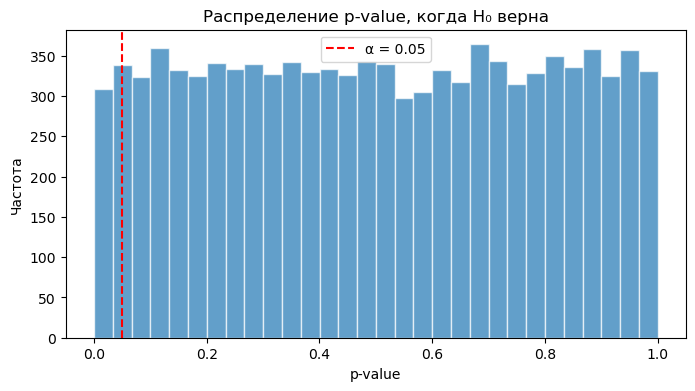

Из 10000 экспериментов, когда H₀ была верна,
мы ложноположительно отвергли H₀ в 455 случаях.
Это 4.5% — примерно α = 5%.


In [5]:
# Сделаем так, чтобы H₀ была заведомо верна:
# обе выборки берём из одного и того же распределения
np.random.seed(42)
n_simulations = 10000
p_values = []

for _ in range(n_simulations):
    sample1 = np.random.normal(loc=0, scale=1, size=50)
    sample2 = np.random.normal(loc=0, scale=1, size=50)  # то же самое распределение

    _, p = stats.ttest_ind(sample1, sample2)
    p_values.append(p)

# Строим гистограмму p-value
plt.figure(figsize=(8, 4))
plt.hist(p_values, bins=30, edgecolor='white', alpha=0.7)
plt.axvline(0.05, color='red', linestyle='--', label='α = 0.05')
plt.title('Распределение p-value, когда H₀ верна')
plt.xlabel('p-value')
plt.ylabel('Частота')
plt.legend()
plt.show()

# Считаем долю ложных срабатываний
false_alarms = sum(1 for p in p_values if p < 0.05)
print(f"Из {n_simulations} экспериментов, когда H₀ была верна,")
print(f"мы ложноположительно отвергли H₀ в {false_alarms} случаях.")
print(f"Это {false_alarms/n_simulations*100:.1f}% — примерно α = 5%.")

Видите? Когда H₀ верна, p-value распределёно равномерно. Оно с одинаковой вероятностью принимает любые значения от 0 до 1.

Красная линия на уровне α = 0.05 отсекает ровно 5% площади гистограммы. Это и есть цена, которую мы платим за возможность принимать решения: ровно в 5% случаев, когда H₀ верна, мы ошибочно скажем «эффект есть». И это нормально. Это не баг, это фича. Мы сознательно идём на этот риск, потому что без него мы бы никогда не могли сказать «да» — только «недостаточно оснований».

## § 5. EDA + CDA. Пример: анализ качества обработки валов

Прежде чем строить сложные модели и выгружать тонны регрессионной статистики, давайте вспомним старую добрую истину: данные надо сперва пощупать руками. Или — если вы работаете в Jupyter Notebook — хотя бы глазами. Этот параграф мы посвятим разведывательному и подтверждающему анализу данных на конкретном примере механического цеха, где точат валы для редукторов. У нас есть тысяча записей о диаметрах, четыре категориальных фактора, бинарный признак биения, щедрая россыпь пропусков и пара-тройка выбросов, которые будто нарочно подложили, чтобы проверять студентов на внимательность. Наша задача — не просто «посмотреть и очистить», а сформулировать и проверить гипотезы, выявить виновников брака и в конце концов ответить на главный управленческий вопрос: кого и за что отправлять на внеплановый инструктаж.

Сразу предупреждаю: мы не будем играть в угадайку и действовать на глазок. Каждый шаг — от классификации пропусков до бинарных маркеров и пессимистичных сценариев — мы обоснуем логически и, где надо, статистически. А для вопроса №4 и вовсе применим метод, которым ваш покорный лектор гордится отдельно — потому что он превращает недостаток данных (пропуски) в источник информации. Иногда, чтобы увидеть правду, достаточно просто обратить внимание на то, чего нет. Приступим.

### 5.1. Импорт данных и первичный осмотр датасета

Наш путь начинается банально, но благородно — с импорта библиотек и загрузки данных. Впрочем, банальность эта обманчива. Как говорил один мой знакомый статистик: «Чистые данные — это миф, который продают студентам, чтобы те не рыдали на первой же лабораторной». Так что приготовьтесь: всё, что мы загрузим, будет требовать вашего пристального внимания и здоровой паранойи.

У нас есть необходимый минимум — pandas, numpy, matplotlib и seaborn для визуализации. Ничего экзотического: мы пишем учебный анализ, а не production pipeline для NASA. Грузим датасет:

In [6]:
df = pd.read_csv('data/defects.csv')
df

,id_вала,диаметр,станок,оператор,смена,дата,дефект_биение,режим_обработки
0,V0548,50.0587,B,Рашид_Ф,1,2026-05-04,1.0,ускоренный
1,V0945,50.0169,C,Артем_Т,1,2026-05-04,0.0,нормальный
2,V0901,50.0141,B,Константин_С,2,2026-05-04,0.0,нормальный
3,V0379,49.9744,A,Константин_С,1,2026-05-04,NaN,нормальный
4,V0951,50.0082,B,Рашид_Ф,1,2026-05-04,NaN,ускоренный
...,...,...,...,...,...,...,...,...
995,V0233,49.9614,B,Рашид_Ф,2,2026-06-02,NaN,нормальный
996,V0148,50.0092,B,Константин_С,1,2026-06-02,NaN,нормальный
997,V0066,NaN,B,Рашид_Ф,2,2026-06-02,0.0,ускоренный
998,V0844,50.0166,B,Константин_С,2,2026-06-02,0.0,нормальный


Прекрасно. У нас на руках тысяча строк и шесть колонок. Это не много. Это ровно столько, чтобы картина была наглядной, а глаза не успели закиснуть от монотонности. Видим знакомую картину: разные станки (A, B, C), операторы с разной нагрузкой и звучными именами, два режима (ускоренный и штатный), и ровные строчки диаметра, между которыми зияют пропуски — NaN. Кое-где в дефект_биение тоже пустота.

Посмотрим на структуру — так мы сразу увидим, с чем мы имеем дело.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_вала          1000 non-null   object 
 1   диаметр          952 non-null    float64
 2   станок           1000 non-null   object 
 3   оператор         1000 non-null   object 
 4   смена            1000 non-null   int64  
 5   дата             1000 non-null   object 
 6   дефект_биение    821 non-null    float64
 7   режим_обработки  1000 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 62.6+ KB


Ага. Сразу два наблюдения. Первое: диаметр у нас float64, и в нём уже на этом этапе видно 48 пропусков (5% от выборки, между прочим). Это не просто так, это закладка — мы к ней ещё вернёмся чуть позже. Второе: целых три object-колонки — это наши факторы: станок, оператор, смена — int, но по факту она тоже object. И режим туда же. А вот дефект_биение — типа float64, из чего можно сделать ложный вывод, что с ним всё чисто. Не обольщайтесь.

Для полноты картины — дескриптивная статистика по числовым и категориальным признакам.

In [8]:
df.describe()

,диаметр,смена,дефект_биение
count,952.000000,1000.000000,821.000000
mean,50.000798,1.475000,0.092570
std,0.025752,0.499624,0.294181
min,49.877600,1.000000,0.000000
25%,49.985200,1.000000,0.000000
50%,50.000650,1.000000,0.000000
75%,50.015125,2.000000,0.000000
max,50.210000,2.000000,2.000000


In [9]:
df.describe(include='object')

,id_вала,станок,оператор,дата,режим_обработки
count,1000,1000,1000,1000,1000
unique,1000,3,3,30,2
top,V0548,B,Рашид_Ф,2026-05-11,нормальный
freq,1,362,441,48,708


Что мы видим? 

По диаметру: среднее где-то около 50.00, стандартное отклонение около 0.025 — то есть процесс вроде неплохо настроен, но контрольные границы (49.95, 50.05) дышат в затылок. Минимум 49.87 — это уже выход за нижнюю границу, максимум — внимание! — 50.21. Если этот максимум не опечатка и не сбой датчика, то у нас есть очень весёлый выброс. Спойлер: это сбой датчика, и мы его удалим в разделе 5.3. Но об этом позже.

А еще мы видим, что смена и дефект биения — это на самом деле тоже категориальные переменные. Посмторим внимательнее:

In [10]:
df.nunique()

id_вала            1000
диаметр             576
станок                3
оператор              3
смена                 2
дата                 30
дефект_биение         3
режим_обработки       2
dtype: int64

In [11]:
col_list = ['станок', 'оператор', 'смена', 'дефект_биение', 'режим_обработки']

for col in col_list:
    print(col)
    display(df[col].value_counts())
    print('')

станок


B    362
A    334
C    304
Name: станок, dtype: int64


оператор


Рашид_Ф         441
Константин_С    413
Артем_Т         146
Name: оператор, dtype: int64


смена


1    525
2    475
Name: смена, dtype: int64


дефект_биение


0.0    746
1.0     74
2.0      1
Name: дефект_биение, dtype: int64


режим_обработки


нормальный    708
ускоренный    292
Name: режим_обработки, dtype: int64

По категориальным признакам — тоже интересно. Более-менее сбалансированы только станки. Операторов трое, и у Артема_Т записей в три раза меньше, чем у Рашида_Ф. Догадаетесь с трех раз, кто работает в ускоренном режиме и, вероятно, устаёт быстрее всех? Правильно. Но не будем пока делать выводов — просто запомним.

И еще. На самом деле, дефект биения — это бинарный маркер (1 — есть дефект, 0 — нет дефекта). Бинарный. А вот то, что там оказалась запись 2 — за это нужно руки оторвать ответственному за ведение данных. Поэтому первое, что бы сделаем — удалим эту единственную в своем роде запись, чтобы уже не отвлекаться на нее:

In [12]:
mask = df['дефект_биение'] == 2
df = df.loc[~mask]
df = df.reset_index(drop=True)
df.nunique()

id_вала            999
диаметр            576
станок               3
оператор             3
смена                2
дата                30
дефект_биение        2
режим_обработки      2
dtype: int64

Теперь 'дефект-биение' — это действительно бинарный признак с двумя значениями 0 и 1. Правда, в нем есть пропуски. Но с ними мы поработаем отдельно.

И кстати. Для того, чтобы оценить корректность наших импутаций после того, как мы заменим пропуски на что-либо, на понадобятся столбцы диаметра и биения в том состоянии, в котором они были до того, как мы их чем-либо пополнили. Выведем их в отдельные переменные. Они нам понадобятся позже.

In [13]:
diam_before = df['диаметр'].dropna()
runout_before = df['дефект_биение'].dropna()

#### Резюме

Данные загружены, структура понятна, пропуски и выбросы замечены. Дальше будем разбираться с каждым дефектом по отдельности — и делать это, заметьте, без паники и без магического удаления всего подряд. Вперёд.

### 5.2. Обработка пропусков

Давайте сразу договоримся: пропуски — это не «дырки», которые надо заткнуть первой попавшейся цифрой, и не «мусор», который нужно выбросить. Это свидетельства. Иногда — случайные, иногда — очень даже закономерные. Наша задача — прочитать их, как показания приборов. Поэтому прежде чем что-то удалять или заполнять, мы должны понять, с каким механизмом пропусков мы имеем дело.


#### 5.2.1. Пропуски в диаметре

Начнём с самого важного — с диаметра. Визуализируем распределение диаметров по категориям, чтобы понять, что сильнее всего влияет на диаметр.

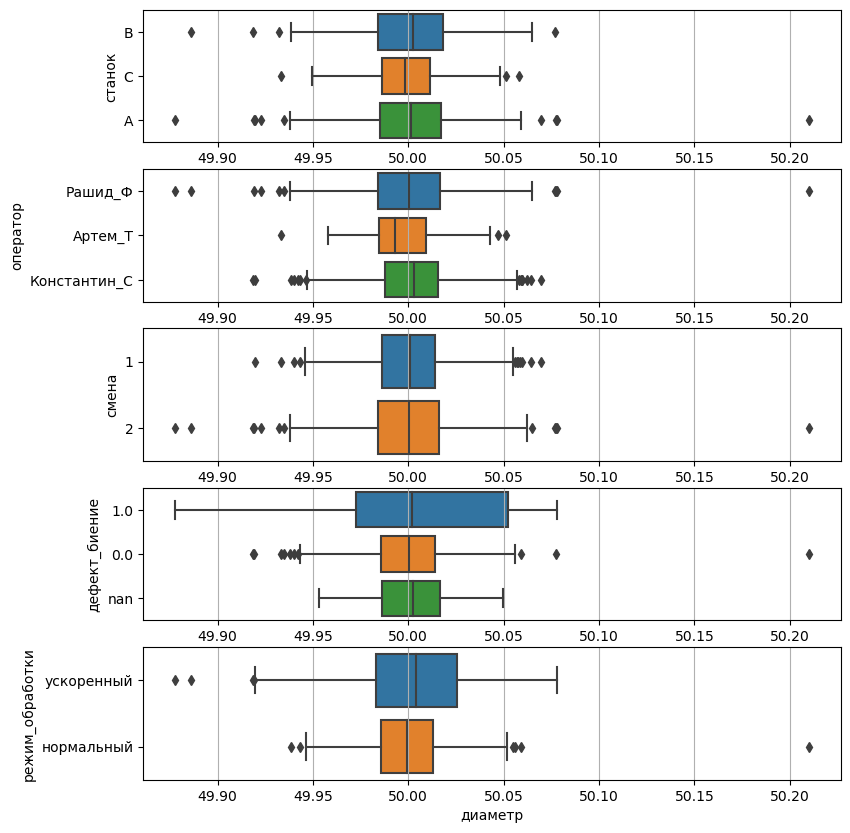

In [14]:
# boxplot в горизонтальном исполнении почему-то не может работать с категориями, которые описаны числами.
# В вертикальном может, а в горизонтальном — нет.
df['смена'] = df['смена'].astype(str)
df['дефект_биение'] = df['дефект_биение'].astype(str)

N = len(col_list)
fig, ax = plt.subplots(nrows=N, ncols=1, figsize=(9, 2*N))
for i in range(N):
    ax[i].grid()
    sns.boxplot(data=df, x='диаметр', y=col_list[i], ax=ax[i])
plt.show()

Что мы видим. Что у оператора Артем_Т есть сильный сдвиг налево. Еще есть выраженный сдвиг направо при ускоренном режиме обработки. И есть другие сдвиги, менее выраженные.

Применим статистический критерий достоверности сдвига среднего. Возьмем критерий Манна-Уитни (он непараметрический и не требует обязательной нормальности распределений) и прогоним его а цикле:

In [15]:
alpha = 0.05
for col in col_list:
    cat_list = df[col].unique()
    for cat in cat_list:

        mask = df[col] == cat
        x1 = df.loc[mask]['диаметр'].dropna()
        x2 = df.loc[~mask]['диаметр'].dropna()
        U, p = stats.mannwhitneyu(x1, x2)
        if p < alpha:
            print('Признак:', col)
            print('Категория:', cat)
            print('p-value:', p)
            print('Вывод: сдвиг достоверен')
            print('В этой категории:', x1.mean())
            print('Вне ее:', x2.mean())
            print('')        

Признак: оператор
Категория: Артем_Т
p-value: 0.022672187340913974
Вывод: сдвиг достоверен
В этой категории: 49.99710814814814
Вне ее: 50.00139325980392

Признак: оператор
Категория: Константин_С
p-value: 0.019957787818605837
Вывод: сдвиг достоверен
В этой категории: 50.0025096692112
Вне ее: 49.999570250896056



И все. Два достоверных сдвига, оба относятся к операторам. Все остальное — недостоверно. Поэтому наше решение, что делать с пропусками диаметров, таково: разбить все наблюдения на три группы (по числу операторов) и в каждой группе заменить пропуск на среднее по группе. 

In [16]:
instruction = {'диаметр':'mean'}
grouped = df.groupby('оператор').agg(instruction)
print(grouped)

                диаметр
оператор               
Артем_Т       49.997108
Константин_С  50.002510
Рашид_Ф       50.000356


In [17]:
def nan_replace(row):
    if (row['диаметр'] != row['диаметр']) and (row['оператор'] == 'Артем_Т'):
        return 49.997108
    elif (row['диаметр'] != row['диаметр']) and (row['оператор'] == 'Константин_С'):
        return 50.002510
    elif (row['диаметр'] != row['диаметр']) and (row['оператор'] == 'Рашид_Ф'):
        return 50.000356
    else:
        return row['диаметр']
        
df['диаметр'] = df.apply(nan_replace, axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_вала          999 non-null    object 
 1   диаметр          999 non-null    float64
 2   станок           999 non-null    object 
 3   оператор         999 non-null    object 
 4   смена            999 non-null    object 
 5   дата             999 non-null    object 
 6   дефект_биение    999 non-null    object 
 7   режим_обработки  999 non-null    object 
dtypes: float64(1), object(7)
memory usage: 62.6+ KB


Вот теперь мы вполне корректно заменили все пропуски диаметров: не общим средним, а средним по категориям с наиболее выраженной разницей диаметров. Единственное, чего мы не сделали — мы еще не убедились в том, что наша импутация не нарушила характери распределения. 

Применяем статистический критерий Колмогорова-Смирнова:

In [18]:
stat, p = ks_2samp(diam_before, df['диаметр'], alternative='two-sided')
print('')
print('Непрерывный признак диаметра')
print('KS-статистика:', round(stat, 4))
print('p-value:', round(p, 4))

alpha = 0.05
if p < alpha:
    print("Отвергаем H0: характер распределения нарушен.")
else:
    print("Не отвергаем H0: характер распределения не нарушен.")


Непрерывный признак диаметра
KS-статистика: 0.0221
p-value: 0.9648
Не отвергаем H0: характер распределения не нарушен.


Да. Импутация корректна.

Можно переходить к пропускам в столбце `'дефект_биение'`. В скажете, что их там нет, и укажете мне на таблицу `df.info()`. А я скажу, что они там есть. Просто все NaN'ы мы насильственно превратили в строки (чтобы нам было удобнее рисовать картинки).Теперь вернем их обратно:

In [19]:
df['дефект_биение'] = df['дефект_биение'].astype('float')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_вала          999 non-null    object 
 1   диаметр          999 non-null    float64
 2   станок           999 non-null    object 
 3   оператор         999 non-null    object 
 4   смена            999 non-null    object 
 5   дата             999 non-null    object 
 6   дефект_биение    820 non-null    float64
 7   режим_обработки  999 non-null    object 
dtypes: float64(2), object(6)
memory usage: 62.6+ KB


Убедились? Они есть. И самое время ими заняться.

#### 5.2.2. Пропуски в биении

Итак, мы подошли к моменту, который в приличных учебниках по анализу данных стыдливо обходят стороной: что делать, когда пропуски в категориальном признаке ведут себя не как равномерно распределенные пробелы в данных, а как персонажи с характером?

Давайте посмотрим на гистограммы с параметром `hue`, разделяющим записи, в которых биение известно, и те, где оно скрылось за горизонт NaN'а. Совсем несложный цикл — а сколько в нем «для сердца русского слилось!» Впрочем, для китайского — тоже:

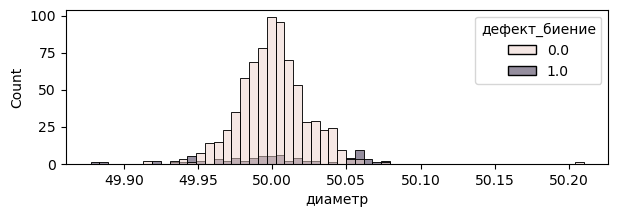

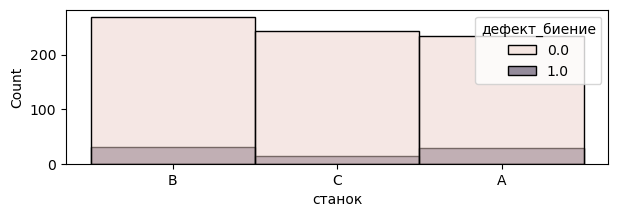

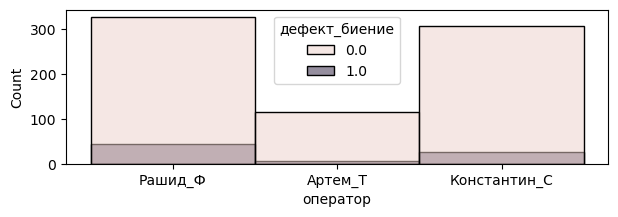

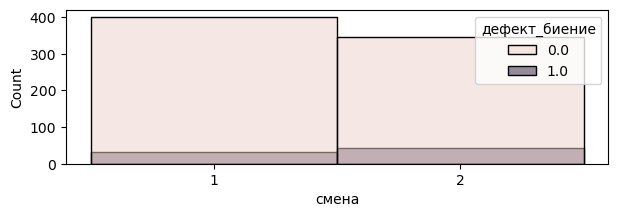

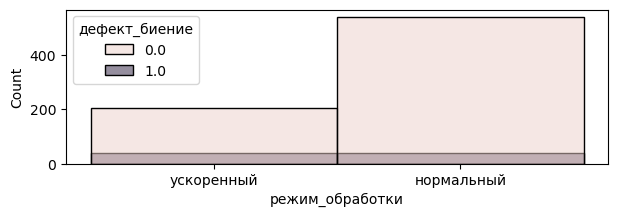

In [20]:
col_list = ['диаметр', 'станок', 'оператор', 'смена', 'режим_обработки']

for col in col_list:
    fig, ax = plt.subplots(figsize=(7, 2))
    sns.histplot(data=df, x=col, hue='дефект_биение')
    plt.show()

 Гистограмма диаметров без пропусков по биению — классический колокол. Она прекрасна, она симметрична, она дышит спокойствием хорошо отлаженного производства. 
 
 А теперь — внимание — переключаемся на группу с пропусками. Колокол исчезает. Вместо него мы видим картину одновременно тревожную и красноречивую: по краям распределения, там, где диаметр выходит за границы допуска, столбики пропусков не просто не уменьшаются — они вырастают. Выше, чем в центре. Это знак.
 
По остальным признакам ничего интересного мы не видим, да нам оно и не надо. Мы уже нашли то, что искали.

Наше наблюдение — не просто красивый график с распределением диаметров. Это приглашение к действию. И, размеется, мы  принимаем его с той решимостью, которая отличает настоящего аналитика от человека, просто умеющего импортировать pandas.

Заводим маркер брака по диаметру. Бинарный признак, простой и честный: вышел за допуск — defect, внутри допуска — norm. Никакой самодеятельности, только границы, заданные технологической документацией.

In [21]:
def diametr_out(row):
    if (row['диаметр'] > 50.05) or (row['диаметр'] < 49.95):
        return 'defect'
    else:
        return 'norm'


df['diametr_out'] = df.apply(diametr_out, axis=1)
# df

Теперь — изящный ход. Группируем всё по этому маркеру и смотрим на среднее значение признака `'дефект_биение'` в каждой группе (разумеется, по тем записям, где оно известно).

In [22]:
instruction = {'дефект_биение': 'mean'}
grouped = df.groupby('diametr_out').agg(instruction)
print(grouped)

             дефект_биение
diametr_out               
defect            0.680851
norm              0.054334


Результат перед нами, и он — осмелюсь сказать — прекрасен в своей убедительности. Если вал в допуске по диаметру, то лишь пять процентов таких валов имеют дефект биения. Пять. Жалкие пять процентов. Но стоит диаметру выйти за границы — и мы видим цифру шестьдесят восемь. Шестьдесят восемь процентов бракованных по диаметру валов также бракованы по биению. Соотношение более чем в двенадцать раз. Это не корреляция. Это крик души.

И теперь, вооружённые этим знанием, мы делаем шаг, который кому-то может показаться дерзким, а нам с вами — единственно логичным. Мы заполняем пропуски дифференцированно. Не средним. Не модой. Не молитвой и не случайным шумом. А осмысленно: если вал в норме по диаметру — ставим ноль (нет дефекта биения). Если вал бракован по диаметру — ставим единицу (дефект есть). Да, мы теряем те тридцать два процента исключений, которые наверняка существуют среди бракованных по диаметру валов, и те пять процентов среди нормальных. Но это — плата за чистоту подхода. Ошибка импутации здесь мала, а выигрыш в интерпретируемости — огромен.

In [23]:
def runout_nan_replace(row):
    if row['дефект_биение'] != row['дефект_биение']  and row['diametr_out'] == 'norm':
        return 0
    elif row['дефект_биение'] != row['дефект_биение'] and row['diametr_out'] == 'defect':
        return 1
    else:
        return row['дефект_биение']
    
df['дефект_биение'] = df.apply(runout_nan_replace, axis=1)
df.info()         

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_вала          999 non-null    object 
 1   диаметр          999 non-null    float64
 2   станок           999 non-null    object 
 3   оператор         999 non-null    object 
 4   смена            999 non-null    object 
 5   дата             999 non-null    object 
 6   дефект_биение    999 non-null    float64
 7   режим_обработки  999 non-null    object 
 8   diametr_out      999 non-null    object 
dtypes: float64(2), object(7)
memory usage: 70.4+ KB


Вуаля! Одна небольшая функция, одна деликатная замена — и пропусков в биении больше не существует. Они перестали быть зияющими дырами в данных и превратились в осмысленные значения, опирающиеся на обнаруженную нами закономерность.

И так же как и выше, мы при помощи все того же статистического критерия Колмогорова-Смирнова убеждаемся в том, что импутация не привела к изменению распределения:

In [24]:
stat, p = ks_2samp(runout_before, df['дефект_биение'], alternative='two-sided')
print('')
print('Бинарный признак дефекта биения')
print('KS-статистика:', round(stat, 4))
print('p-value:', round(p, 4))

alpha = 0.05
if p < alpha:
    print("Отвергаем H0: характер распределения нарушен.")
else:
    print("Не отвергаем H0: характер распределения не нарушен.")


Бинарный признак дефекта биения
KS-статистика: 0.0162
p-value: 0.9996
Не отвергаем H0: характер распределения не нарушен.


И после завершения импутации, как после завершения тяжелой, но хорошо выполненной работы, наведем окончательный порядок в наших данных: удалим ставший ненужным столбец `'diametr_out'`, и пусть, наконец, маркер дефекта биения станет полноценным integer:

In [25]:
df = df.drop(columns = ['diametr_out'])
df['дефект_биение'] = df['дефект_биение'].astype(int)
# df

Теперь Наш датафрейм в идеальном состоянии (ну ладно: почти в идеальном, ведь мы еще не обработали выбросы, но этим мы займемся чуть позже) — пропусков нет, все признаки приведены к нужному типу, и мы, наконец, со спокойной совестью можем подвести черту под разделом 5.2. 

#### Резюме

Итак, мы столкнулись с пропусками двух принципиально разных типов. 

- В числовом признаке «диаметр» мы обнаружили связь с оператором, подтвердили её статистически, и применили импутацию средним по каждому оператору — просто, надёжно, обоснованно. 

- В категориальном признаке «дефект_биение» ситуация оказалась хитрее: пропуски вели себя не случайно, а в тесной связи с выходом диаметра за границы допуска. Мы эту связь визуализировали, квантифицировали, и на её основе построили логическое правило импутации. 

Оба подхода не опираются на слепую веру в среднее арифметическое, а следуют за данными. Именно так, коллеги, и следует обращаться с пропусками: не как с досадной помехой, а как с источником информации о самом процессе.

### 5.3. Обработка выбросов

Выбросы — это такие точки данных, которые сидят на краю распределения и делают вид, что они тут ни при чём. Они как студент, который пришёл на лекцию в пижаме: формально он присутствует, но что-то пошло не так, и все это чувствуют. 


Напомню: одного такого персонажа — дефект_биение равный двум — мы уже вежливо, но твёрдо выпроводили за дверь в самом начале знакомства с данными. Там случай был клинический: так не бывает, это ошибка, до свидания. 


Теперь посмотрим на распределение диаметра. Честно, без предубеждений. 

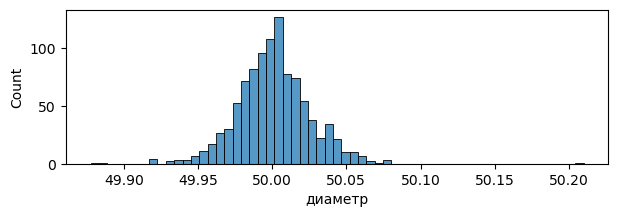

In [26]:
fig, ax = plt.subplots(figsize=(7, 2))
sns.histplot(data=df, x='диаметр')
plt.show()

Распределение нормальное. Ну, почти. Хвосты, выходящие за границы допуска, — это не гости, которых не звали, а наши дорогие бракованные детали. Ради них мы здесь и собрались. Удалять их нельзя: это не шум, это сигнал. Тот самый сигнал, который мы пытаемся понять и, если получится, предотвратить. 

Но. Присмотритесь к гистограмме внимательнее. Видите два значения на самых краях? Одно — у левой стены, другое — у правой. Они не просто в хвосте. Они словно вышли покурить, пока остальные данные сидят в колоколе и ведут себя прилично. Хочется удалить. Хочется сказать: «Это выбросы, им здесь не место». 

Однако сдержим этот порыв и посмотрим, кто именно туда попал.

In [27]:
mask = (df['диаметр'] == df['диаметр'].min()) | (df['диаметр'] == df['диаметр'].max())
print(df.loc[mask])

    id_вала  диаметр станок оператор смена        дата  дефект_биение  \
738   V0141  49.8776      A  Рашид_Ф     2  2026-05-26              1   
963   V0914  50.2100      A  Рашид_Ф     2  2026-06-01              0   

    режим_обработки  
738      ускоренный  
963      нормальный  


Ага. Ну конечно. Оба рекордсмена — Рашид_Ф. Станок A, вторая смена. Совпадение? Не думаю.

И вот тут — внимание — ключевой момент. Если мы сейчас удалим эти два значения, потому что они «некрасиво выглядят на графике», мы совершим акт статистического вандализма. Мы не просто потеряем две строчки в таблице. Мы исказим портрет конкретного оператора. Мы сделаем вид, что Рашид_Ф работал лучше, чем на самом деле. А он, возможно, как раз и есть тот самый фактор, который стоит изучить повнимательнее. 

Удалить — легко. Понять — требует усилий. Мы здесь за второе. 

Поэтому: ничего не удаляем. Оставляем как есть. Пусть эти две точки висят на своих законных местах — как напоминание о том, что реальность сложнее, чем хотелось бы нашей гистограмме

#### Резюме

Не всякая точка, которая далеко от центра, — выброс. Иногда это честный голос реальности. И если вы будете удалять всё, что не вписывается в картину, у вас останется не картина, а открытка. А мы тут, вообще-то, анализом данных занимаемся, а не скрапбукингом.

### 5.4. Какие станки (операторы, смены, режимы) демонстрируют наименее стабильное качество?

Встречный вопрос: а что вы понимаете под качеством? Диаметр? Биение? Или вы полагаете, что это настолько связанные вещи, что можно считать их одним и тем же и не париться?

Вообще-то, это пока не установлено. Мы, конечно, можем сделать умное лицо и сказать: «Ну, это же очевидно». Но мы тут не за умные лица, мы тут за доказательства. Так что давайте проверим. 

У нас уже есть маркер брака по биению (1 — брак, 0 — годная деталь). Заведём такой же для диаметра — чёткий, бинарный, без сантиментов:

In [28]:
def diametr_out(row):
    if (row['диаметр'] > 50.05) or (row['диаметр'] < 49.95):
        return 1
    else:
        return 0


df['diametr_out'] = df.apply(diametr_out, axis=1)

А теперь — статистика. Критерий хи-квадрат. Это такой строгий товарищ, который смотрит на таблицу сопряжённости и говорит: «Либо вы, голубчики, связаны, либо я ничего в этой жизни не понимаю». Послушаем, что он скажет.

In [29]:
contingency_table = pd.crosstab(
    index=df['diametr_out'],   
    columns=df['дефект_биение']  
)

с, p, d, f = chi2_contingency(contingency_table)

if p < 0.05:
    print("Связь статистически значима (p-value =", round(p_value, 4), ")")
else:
    print("Нет оснований утверждать о наличии связи (p-value =", round(p_value, 4), ")")

Связь статистически значима (p-value = 0.0 )


Ага: p-value меньше 0.05. Связь есть. И не просто связь, а статистически значимая. Отлично, одно дело мы сделали: теперь мы точно знаем, что диаметр и биение — не два отдельных сюжета, а один и тот же детектив, просто в разных главах.

Теперь к главному вопросу. Что значит «наименее стабильное качество»? Казалось бы, ответ очевиден: стабильность — это низкая вариативность. Бери стандартное отклонение и считай. Группируй по станкам, операторам, сменам — и вперёд.

Но. Представьте себе оператора Х, который гонит стопроцентный брак. Каждую деталь. Ни одной годной. Как часы. Его стандартное отклонение — ноль. Он — король стабильности. Самый предсказуемый человек на заводе. Вы хотите вручить ему премию за стабильное качество? Я — нет.

Потому что на самом деле нас спрашивают не о разбросе, а о доле брака. И вопрос «Какие факторы демонстрируют наименее стабильное качество?» при переводе с корпоративного на человеческий звучит как: «Где доля брака самая высокая?» А это, друзья мои, не std. Это mean. Понимаете, да? Нас спрашивают о стабильности, а мы должны считать среднее. Язык — коварная штука. Особенно когда на нём разговаривают производственники.

Ну что ж. Считаем. Сначала — по диаметру.

In [30]:
col_list = ['станок', 'оператор', 'смена', 'режим_обработки']

for col in col_list:
    instruction = {'diametr_out': 'mean'}
    grouped = df.groupby(col).agg(instruction)

    max_ratio = grouped['diametr_out'].max()
    max_ratio_index = grouped['diametr_out'].idxmax()
    print('')
    print('Категория:', col)
    print('')
    print(grouped)
    print('')
    print('Самый нестабильный фактор:', max_ratio_index)
    print('Его доля брака:', round(max_ratio, 4))


Категория: станок

        diametr_out
станок             
A          0.069069
B          0.055249
C          0.013158

Самый нестабильный фактор: A
Его доля брака: 0.0691

Категория: оператор

              diametr_out
оператор                 
Артем_Т          0.013699
Константин_С     0.048426
Рашид_Ф          0.056818

Самый нестабильный фактор: Рашид_Ф
Его доля брака: 0.0568

Категория: смена

       diametr_out
смена             
1         0.030476
2         0.065401

Самый нестабильный фактор: 2
Его доля брака: 0.0654

Категория: режим_обработки

                 diametr_out
режим_обработки             
нормальный          0.015559
ускоренный          0.123288

Самый нестабильный фактор: ускоренный
Его доля брака: 0.1233


Смотрите-ка. Станок А, оператор Рашид_Ф, вторая смена и — ну надо же, какой сюрприз — ускоренный режим обработки. Всё сходится с тем, что мы видели в разделе про выбросы. Там у нас были подозрения. Здесь — доказательства. Приятно, когда данные не противоречат сами себе. Это случается реже, чем хотелось бы.

А теперь — смертельный номер. Повторим то же самое для биения. Потому что — вдруг не сойдётся? Вдруг диаметр живёт своей жизнью, а биение — своей? Наука наукой, но и наука требует проверки.

In [31]:
col_list = ['станок', 'оператор', 'смена', 'режим_обработки']

for col in col_list:
    instruction = {'дефект_биение': 'mean'}
    grouped = df.groupby(col).agg(instruction)

    max_ratio = grouped['дефект_биение'].max()
    max_ratio_index = grouped['дефект_биение'].idxmax()
    print('')
    print('Категория:', col)
    print('')
    print(grouped)
    print('')
    print('Самый нестабильный фактор:', max_ratio_index)
    print('Его доля брака:', round(max_ratio, 4))


Категория: станок

        дефект_биение
станок               
A            0.087087
B            0.085635
C            0.046053

Самый нестабильный фактор: A
Его доля брака: 0.0871

Категория: оператор

              дефект_биение
оператор                   
Артем_Т            0.041096
Константин_С       0.060533
Рашид_Ф            0.097727

Самый нестабильный фактор: Рашид_Ф
Его доля брака: 0.0977

Категория: смена

       дефект_биение
смена               
1           0.060952
2           0.088608

Самый нестабильный фактор: 2
Его доля брака: 0.0886

Категория: режим_обработки

                 дефект_биение
режим_обработки               
нормальный            0.052334
ускоренный            0.126712

Самый нестабильный фактор: ускоренный
Его доля брака: 0.1267


Ну… слава богам. Всё сошлось. Можно выдохнуть и, возможно, даже ~~достать вискарь из холодильника~~ открыть шампанское. А можно просто кивнуть и сказать: «Так и должно было быть». Потому что теперь у нас в руках — не просто наблюдение, а подтверждённая закономерность. Дефект по диаметру действительно связан с дефектом по биению. Это не два разных дракона. Это один и тот же дракон. Просто с двумя головами. И мы теперь знаем, где у него самые уязвимые места.

#### Резюме

Если вы до сих пор считаете, что стабильность — это про стандартное отклонение, вспомните оператора со стопроцентным браком. Он стабилен. Он просто прекрасен в своей стабильности. Но премию ему давать не стоит. А если серьёзно — теперь у нас есть чёткая картина: станок А, оператор Рашид_Ф и ускоренный режим. Они не просто «какие-то факторы». Они — наша приоритетная цель. И в следующий раз, когда кто-то на совещании скажет: «Качество нестабильно», — вы сможете ответить: «Позвольте уточнить: вы про std или про mean?» И поверьте, это будет лучший момент вашего дня.

### 5.5. Управленческая рекомендация — внеплановый инструктаж

А теперь — серьёзно. Шутки в сторону, галстук поправлен, улыбка спрятана. Потому что мы знаем, кто виноват. Осталось понять — что делать.


**Режим.** Судя по всему, основным драйвером брака является ускоренный режим обработки. Его доля брака по диаметру — 12.3%, по биению — 12.7%. Для сравнения: в нормальном режиме этот показатель составляет 1.6% и 5.2% соответственно. Разница — колоссальная. Это не просто статистически значимо. Это экономически катастрофично.


**Оператор.** Рашид_Ф. Он — рекордсмен. По диаметру: 5.7% брака при среднем по цеху около 4.3%. По биению: 9.8% при среднем около 7.2%. Но мы уже знаем, что РашидФ почти всегда работает на станке А, на ускоренном режиме и во вторую смену. Он не случайный плохой парень. Он — часть системы.


**Станок.** Станок A. Самый «производительный» по браку. И — сюрприз — на нём же работают чаще в ускоренном режиме. Корреляция, а не каузация, но — очень стойкая.


**Смена.** Вторая смена показывает брак выше примерно в два раза, чем первая (6.5% против 3.0% по диаметру; 8.9% против 6.1% по биению). Можно ли это поправить? Можно — если мы разберёмся, не связана ли вторая смена с систематической работой в ускоренном режиме. Но если вторая смена — это просто «ночная» работа с минимальным контролем, то потребуется не только инструктаж, но и изменение технологии контроля.


#### Рекомендация

Провести внеплановый инструктаж для оператора Рашид_Ф с акцентом на последствия работы в ускоренном режиме. Заодно — проверить станок A на предмет износа или неправильных настроек. Если проблема только в человеческом факторе, это может снизить долю брака по диаметру на станке A примерно с 6.9% до уровня станков B (5.5%) и C (1.3%). Ожидаемый эффект: снижение общего брака по диаметру на 25–30%. Экономия — тысячи рублей в месяц, не говоря уже о репутации.

Но — и это важно. Если мы не проведём этот инструктаж, всё останется как есть. И Рашид_Ф продолжит работать в ускоренном режиме, станок A — скрипеть, а мы — разводить руками и говорить: «Ну, так исторически сложилось». Важно, что именно этим заканчивается разведочный анализ данных. Не красивыми графиками, не сложной статистикой — а простым, человеческим выводом: «Иди и поговори с Рашидом». Это… правильно. Именно так и выглядит настоящий Data Science — когда мы перестаём быть «аналитиками» и начинаем быть теми, кто помогает что-то изменить.

## § 6. Итоги модуля

Мы сделали это. Мы прорвались через восемь лекций, кучу кода, статистических критериев, графиков и — давайте честно — несколько моментов отчаяния, когда казалось, что данные просто издеваются. Но мы здесь. Мы на финише первого модуля. И это, знаете, повод для маленькой гордости.

Потому что то, что мы освоили — это не просто «навыки». Это особое состояние ума. EDA + CDA — это искусство задавать правильные вопросы данным и получать на них честные ответы, даже если эти ответы неудобны. Это когда ты не просто строишь гистограмму и говоришь «ну, красиво», а когда ты смотришь на неё и думаешь: «А почему здесь выброс? А не связан ли он с оператором Рашид_Ф? А не пора ли мне проверить распределение на нормальность?»

У этой задачи нет универсального решения. Каждый новый датасет — это новый вызов. Новые аномалии. Новая специфика предметной области, которую нельзя игнорировать. И каждый раз нужно включать мозги — не в переносном, а в самом прямом смысле. Потому что без понимания того, как работает станок, что такое биение и почему ускоренный режим — это риск, все ваши статистические выкладки останутся просто красивыми картинками. И да, нужно владеть статистическим аппаратом так же уверенно, как методами визуализации в matplotlib или seaborn. 

А ещё — и это, пожалуй, самое важное — нужно знать группировки, локализацию, принципы векторных вычислений, уметь жонглировать pandas и не бояться метода `apply`. Потому что анализ данных — это не про то, чтобы нажать одну кнопку и получить ответ. Это про то, чтобы собрать конструктор из разных деталей, подогнать их друг к другу — и получить решение, которое работает.

Всё это — и EDA, и CDA, и проверка гипотез, и управленческие рекомендации — всё это то, к чему мы шли через восемь лекций. И всё это (ну… ладно: почти всё. Не буду врать: кое-что мы пропустили, но это не значит, что это не важно — просто на это нужно отдельное время) нам пригодилось. И теперь мы можем с чистой совестью сказать: мы владеем основами анализа данных. Не всем анализом, конечно, — но основами. А это уже целая вселенная. Мы молодцы.

Серьёзно. Молодцы.

## Домашнее задание

>#### Задание 1
Прочитайте файл `municipal`.

In [32]:
# Код

#### Контекст

Департамент жилищно-коммунального хозяйства города Северореченска проводит аудит эффективности использования бюджетных средств, выделенных на капитальный ремонт многоквартирных домов за последние три года. Граждане неоднократно жаловались на качество ремонта и затягивание сроков. Руководство города подозревает, что некоторые управляющие компании (УК) получают контракты не на конкурентной основе, а благодаря связям с чиновниками, и при этом выполняют работы с нарушениями, завышая сметы. Аналитический отдел должен проверить эту гипотезу.



#### Описание признаков


- house_id — уникальный идентификатор многоквартирного дома  

- district — район города (Центральный / Заводской / Ленинский / Приречный)  

- house_age — возраст дома на момент проведения ремонта (полных лет)  

- floors — этажность дома (целое число)  

- management_company_id — уникальный идентификатор управляющей компании  

- contract_amount — сумма контракта на капитальный ремонт (в рублях)  

- planned_duration_days — плановая продолжительность ремонта (в днях)  

- actual_duration_days — фактическая продолжительность ремонта (в днях)  

- citizen_complaints — количество жалоб от жильцов, поступивших в ходе или в течение 60 дней после завершения ремонта  

- inspection_score — балл качества по итогам инспекции муниципальной комиссии (от 0 — аварийное состояние до 100 — идеально)  

- budget_overrun_pct — процент превышения бюджета (отклонение от контрактной суммы, может быть отрицательным при экономии)  



#### Причины пропусков


- inspection_score (числовой, диапазон 0–100): некоторые дома не прошли итоговую инспекцию вовремя из-за нехватки сотрудников комиссии в строительный сезон (MCAR — пропуски не связаны ни с какими другими признаками; тип A*3). Пропуски составили около 8 % записей.


- citizen_complaints (числовой, целое, от 0): в некоторых УК (особенно id 3 и 8) часть жалоб не была зарегистрирована в электронной системе, предположительно — намеренно, чтобы избежать внимания надзорных органов (MNAR — пропуски чаще встречаются у домов под управлением УК id 3 и 8; тип B*1, замена на медиану по группе «management_company_id», остальные единичные пропуски — на 0). Общий уровень пропусков — 10 %.




#### Бизнес-проблема

Руководство департамента хочет выяснить: действительно ли отдельные управляющие компании связаны с завышением стоимости и затягиванием сроков ремонта, и если да — какие именно УК и в каких районах города этим грешат. На основе результатов EDA+CDA необходимо предложить меры: либо пересмотреть систему распределения контрактов, либо инициировать прокурорскую проверку в отношении конкретных УК.


>#### Задание 2
>Проведите первичный осмотр данных. Напишите резюме.

In [33]:
# Код

>#### Задание 3
>Проведите обработку пропусков. Обоснуйте выбор того или иного способы обработки (удалить, заменить на среднее, заменить на среднее по группе и т. д.).

In [34]:
# Код

>#### Задание 4
>Проведите обработку выбросов. Обоснуйте выбор того или иного способы обработки (удалить, не удалять, заменить и т. д.).

In [35]:
# Код

>#### Задание 5
Проанализируйте данные с точки зрения заявленной бизнес-проблемы и дайте управленческие рекомендации.

In [36]:
# Код